In [1]:
#import libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [15]:
#create dataste
data = {
    "House":[2,3,4,5,6,7,8,9,10,11],
    "Attendance":[60,65,70,75,80,85,90,92,98,99],
    "Pass":[0,0,0,0,1,1,1,1,1,1]
}

df = pd.DataFrame(data)
print(df)

   House  Attendance  Pass
0      2          60     0
1      3          65     0
2      4          70     0
3      5          75     0
4      6          80     1
5      7          85     1
6      8          90     1
7      9          92     1
8     10          98     1
9     11          99     1


In [16]:
# prepare the data




x = df[["House", "Attendance"]]
y = df["Pass"]

# Split the data
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Scale the features
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [9]:
model = Sequential()
model.add(Dense(8,activation="relu",input_shape=(2,)))
model.add(Dense(4,activation="relu"))
model.add(Dense(1,activation="sigmoid"))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [18]:
history = model.fit(
    x_train,
    y_train,
    epochs =100,
    batch_size = 2,
    validation_split = 0.2
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - accuracy: 0.6667 - loss: 0.4755 - val_accuracy: 0.5000 - val_loss: 0.5306
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6667 - loss: 0.4743 - val_accuracy: 0.5000 - val_loss: 0.5290
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6667 - loss: 0.4721 - val_accuracy: 0.5000 - val_loss: 0.5266
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6667 - loss: 0.4696 - val_accuracy: 0.5000 - val_loss: 0.5240
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6667 - loss: 0.4678 - val_accuracy: 0.5000 - val_loss: 0.5222
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6667 - loss: 0.4659 - val_accuracy: 0.5000 - val_loss: 0.5209
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6667 - loss: 0.4639 - val_accuracy: 0.5000 - val_loss: 0.5197
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6667 - loss: 0.4620 - val_accuracy: 0.5000 - val_loss

In [19]:
loss,accuracy = model.evaluate(x_test,y_test)
print("Accuracy",accuracy)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.5000 - loss: 0.3598
Accuracy 0.5


In [20]:
sample = np.array([[8,90]])
sample = scaler.transform(sample)
prediction = model.predict(sample)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[[0.93286896]]


In [25]:
# data ko visulize karne ke liye import...
!pip install graphviz

MODEL SUMMARY


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)


Architecture saved successfully as ann_model.png


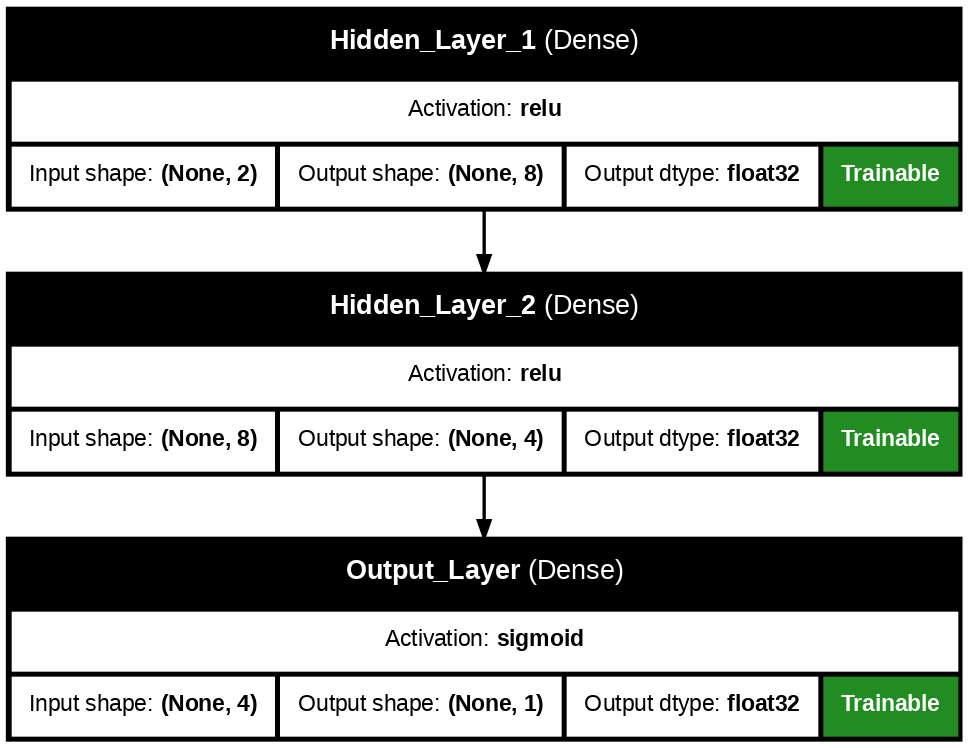

In [26]:
# ==========================================================
# ANN Architecture Visualization (Keras 3 Compatible)
# ==========================================================

# Install Graphviz (Run only in Google Colab)
# Uncomment these two lines if using Colab

# !apt-get install graphviz -y
# !pip install pydot graphviz

# ==========================================================
# Import Libraries
# ==========================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import plot_model

# ==========================================================
# Build ANN Model
# ==========================================================

model = Sequential([
    Input(shape=(2,), name="Input_Layer"),

    Dense(
        units=8,
        activation='relu',
        name="Hidden_Layer_1"
    ),

    Dense(
        units=4,
        activation='relu',
        name="Hidden_Layer_2"
    ),

    Dense(
        units=1,
        activation='sigmoid',
        name="Output_Layer"
    )
])

# ==========================================================
# Compile Model
# ==========================================================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ==========================================================
# Print Model Summary
# ==========================================================

print("="*60)
print("MODEL SUMMARY")
print("="*60)

model.summary()

# ==========================================================
# Save Architecture Diagram
# ==========================================================

plot_model(
    model,
    to_file="ann_model.png",
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    show_layer_activations=True,
    show_trainable=True,
    dpi=120
)

print("\nArchitecture saved successfully as ann_model.png")

# ==========================================================
# Display Image (Google Colab / Jupyter Notebook)
# ==========================================================

from IPython.display import Image, display

display(Image("ann_model.png"))

In [ ]:
# create a project on Employee salary prediction
# feature:- Experisence, Education, Skills, Company_size, Location,
# traget = salary